# TRIDENT for CGM-oriented experiments

In the last tutorial, we already saw how to deal with the basics of a TNG dataset, and also some basic functionalities of TRIDENT.
Now, we will aim to use TRIDENT to create mock spectra by piercing our already downloaded subhalo. 

In particular:
- We will produce several commonly explored absorption lines mock spectra. 
- Explore how to include the effect of spectral resolution and pixel dispersion in our mock spectra. 
- Finalize with an experiment of studying the kinematics of the gas from an edge-on view of the galaxy. 

## TRIDENT in a nutshell

[TRIDENT](https://iopscience.iop.org/article/10.3847/1538-4357/aa7e2d/pdf) works in a three-step fashion. First, for a given dataset it estimates the ions component of a given desired species not tracked by the dataset. For example, TNG tracks both HI and HII, but it does not track any ions for metals, and therefore their contents needs to be estimated before hand. To do this estimation, TRIDENT assumes ionization equilibrium to estimate the ionization fraction ($f_{X_i}$) of a given ion. Under those circumstances, $f_{X_i}$ is a function of density, temperature and the background radiation field (which depends mostly on redshift). A visual summary is shown in the figure. 

<div style="text-align: center;">
    <img src="images/trident_summary.jpg" width="300"/>
</div>

After successfully estimating the ions component of a given dataset, the user can trace a ray that pierces the dataset to produce. Each produced ray will store the necessary information to then produce the corresponding absorption spectrum, which corresponds to the temperature, ion number density, and projected velocity along the ray. 

Finally, for each pierced resolution element of the simulation, a Voigt profile is deposited assuming a non-turbulent regime (i.e., the doppler parameter only considers thermal broadening). 

After the spectrum is created, it can be further post-processed to obtain a more realistic outcome comparable to real observations.

In [1]:
# Importing all essentials 
import numpy as np
import matplotlib.pyplot as plt 
import plotting_setup # comment this line if running local
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import coordinates as coords
import os

import illustris_python as ill 
import trident
import yt
import yt.units
from yt.units import kpc


c:\ProgramData\Anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
def fit_delta_crit(x):
    # Extracted from Bryan 1998 (fit with Omega_R = 0)
    return 18*np.pi**2 + 82*x - 39*(x**2)

def virial_radius(M, z):
    # Mass has to be given in units of solar masses
    cosmo = FlatLambdaCDM(H0 = 67.74, Om0=0.3089, Ob0=0.0486)
    density = fit_delta_crit(cosmo.Om(z) - 1) * cosmo.critical_density(z)
    
    # density = 200 * cosmo.critical_density(z)  use this to use typical TNG definition of the virial radius

    density = density.to(u.M_sun/u.kpc**3)
    r_cube = (3/(4*np.pi*density)) * (M*u.M_sun)

    return r_cube**(1/3)

**Note:** always check the TRIDENT database of absorption lines. This is typically found in the installation folder. This database includes all the necessary information to produce a Voigt profile for a given species, like the oscillator strength, the damping constant and the rest-frame wavelength. 

In [3]:
# Check TRIDENT path
trident.__path__

['c:\\ProgramData\\Anaconda3\\lib\\site-packages\\trident']

In [4]:
# Extracting relevant information from the group catalogs
basePath = 'D:/TNG-and-TRIDENT-for-CGM-oriented-science'

fields = ['SubhaloSFRinHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloSFR', 'SubhaloPos', 
          'SubhaloVel' , 'SubhaloGrNr' , 'SubhaloMass', 'SubhaloCM'] 

subhalos_catalog = ill.groupcat.loadSubhalos(basePath, 50,fields=fields) 

# We will also add the units accordingly 

center = subhalos_catalog['SubhaloCM'][110863] # we will left this with code units         
velocity_gal = subhalos_catalog['SubhaloVel'][110863] * (yt.units.km / yt.units.s) 
total_mass = subhalos_catalog['SubhaloMass'][110863] * (1e10/0.6774) * yt.units.Msun 

In [5]:
R_vir = virial_radius(total_mass, 1) 

In [6]:
# Now we load our dataset with yt!
ds = yt.load('cutout_10.hdf5') 

# We add the ion fields to our dataset :) 
trident.add_ion_fields(ds, ions = ['Mg II', 'C IV', 'Fe II']) # we only need to add the missing ions (HI is already tracked in TNG)

yt : [INFO     ] 2025-06-27 13:32:53,110 Calculating time from 5.007e-01 to be 1.855e+17 seconds
yt : [INFO     ] 2025-06-27 13:32:53,211 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:32:53,212 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:32:53,213 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-27 13:32:53,214 Parameters: domain_right_edge         = [35000. 35000. 35000.]
yt : [INFO     ] 2025-06-27 13:32:53,215 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:32:53,217 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:32:53,218 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:32:53,218 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:32:53,219 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:32:53,220 Parameters: hubble_constant

Let's create our first ray that will through the center of this galaxy. To do that, we only need to specify a starting and and ending point. We will go through the center of this galaxy moving 2 times the virial radius in the $\hat{z}$ direction of the coordinates of the simulation. 

In [ ]:
center_kpc = center * ds.length_unit.in_units('kpc')

starting_point = [center_kpc[0], center_kpc[1], center_kpc[2] - R_vir.value * kpc]
ending_point = [center_kpc[0], center_kpc[1], center_kpc[2] + R_vir.value * kpc]

# We will define the lines we want to produce 
# TRIDENT nomenclature is Atom Ionization Rest wavelength (rounded to the closest integer) 
# Also, if you want to generate all lines for a given species, you can just 
lines_list = ['H I','Mg II 2796', 'Mg II 2804', 'Fe II 2344', 'C IV 1548', 'C IV 1551'] 

Let's create some folders to save the rays and spectra. 

In [ ]:
%%bash
mkdir rays
mkdir spectra

In [ ]:
# Now we create our ray
ray = trident.make_simple_ray(ds,
                                start_position=starting_point,
                                end_position=ending_point,
                                data_filename="rays/ray_DTB.h5",
                                lines=lines_list, line_database='database_tutorial.txt', 
                                fields=[('PartType0', 'H_p1_number_density')])   # I'm additionally asking for the ray to save HII :) 

yt : [INFO     ] 2025-06-27 12:50:43,769 Getting segment at z = 0.9972942257819404: [0.76683243 0.09175672 0.18873075] unitary to [0.76683243 0.09175672 0.20212618] unitary.
C:\ProgramData\Anaconda3\lib\site-packages\unyt\array.py:1906: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
yt : [INFO     ] 2025-06-27 12:50:43,774 Getting subsegment: [0.76683243 0.09175672 0.18873075] unitary to [0.76683243 0.09175672 0.20212618] unitary.
yt : [INFO     ] 2025-06-27 12:50:55,044 Saving field data to yt dataset: rays/ray_DTB.h5.
yt : [INFO     ] 2025-06-27 12:50:55,112 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 12:50:55,115 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 12:50:55,118 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 12:50:55,120 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 12:50:55

We can explore the density probed along the ray.

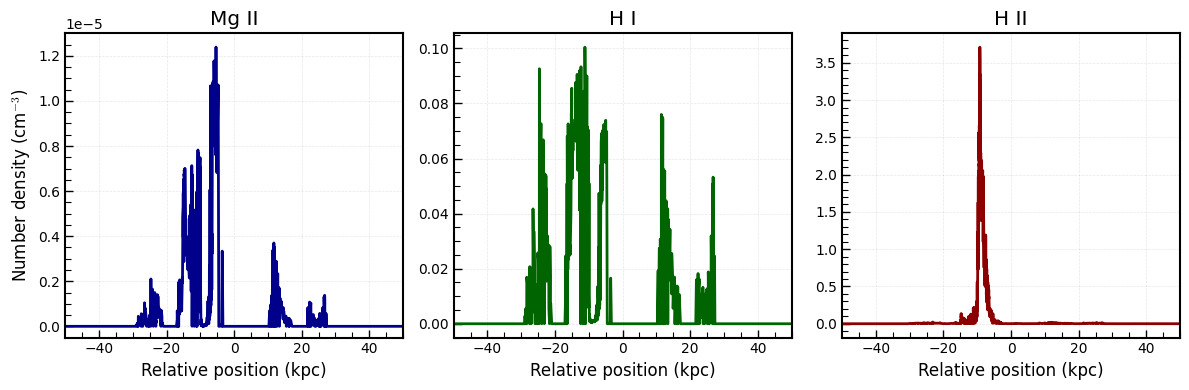

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
relative_position = ray.data[('gas', 'l')].to('kpc') - R_vir.value * kpc

# Panel 1: Mg II number density
axs[0].plot(relative_position, ray.data[('all', 'Mg_p1_number_density')], color='darkblue')
axs[0].set_xlim(-50, 50)
axs[0].set_ylim(-0.5e-6, 1.3e-5)
axs[0].set_xlabel('Relative position (kpc)')
axs[0].set_ylabel(r'Number density (cm$^{-3}$)')
axs[0].set_title(r'Mg II')
axs[0].grid(True, alpha=0.3)

# Panel 2: H I number density
axs[1].plot(relative_position, ray.data[('all', 'H_p0_number_density')], color='darkgreen')
axs[1].set_xlim(-50, 50)
axs[1].set_xlabel('Relative position (kpc)')
axs[1].set_title(r'H I')
axs[1].grid(True, alpha=0.3)

# Panel 3: H II number density
axs[2].plot(relative_position, ray.data[('all', 'H_p1_number_density')], color='darkred')
axs[2].set_xlim(-50, 50)
axs[2].set_xlabel('Relative position (kpc)')
axs[2].set_title(r'H II')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# We can even compute total column densities from the data stored in the ray
HI_column_density = (ray.r[('gas', 'H_p0_number_density')] * ray.r[('all', 'dl')]).sum()
MgII_column_density = (ray.r[('gas', 'Mg_p1_number_density')] * ray.r[('all', 'dl')]).sum()
FeII_column_density = (ray.r[('gas', 'Fe_p1_number_density')] * ray.r[('all', 'dl')]).sum()

print('The total HI column density probed is: {:.2e}'.format(HI_column_density)) 
print('The total MgII column density probed is: {:.2e}'.format(MgII_column_density)) 
print('The total FeII column density probed is: {:.2e}'.format(FeII_column_density)) 

The total HI column density probed is: 8.97e+20 cm**(-2)
The total MgII column density probed is: 5.46e+16 cm**(-2)
The total FeII column density probed is: 3.84e+16 cm**(-2)


Now, we can create our spectrum! 

In [9]:
spectra_path = 'spectra/'
z = ds.current_redshift

ray_name = 'rays/ray_DTB.h5'
name_spectrum = spectra_path + f'spectrum_DTB.txt'
min_lambda = (1+z) * 950 # shortest wavelength will come from Lyman gamma at ~972 A
max_lambda = (1+z) * 2825 # longest wavelength will come from Mg II at ~2800 A
    
sg = trident.SpectrumGenerator(lambda_min=min_lambda, lambda_max=max_lambda,
                                   dlambda=0.01,                                   # The equivalenth of "pixel dispersion" 
                                   line_database='database_tutorial.txt')           # Very important to change it accordingly!
sg.make_spectrum(ray_name, lines=lines_list)
sg.save_spectrum(name_spectrum)

yt : [INFO     ] 2025-06-27 12:49:30,589 Setting instrument to Custom
yt : [INFO     ] 2025-06-27 12:49:30,672 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 12:49:30,676 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 12:49:30,679 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 12:49:30,683 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 12:49:30,683 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 12:49:30,685 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 12:49:30,686 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 12:49:30,686 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 12:49:30,687 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 12:49:30,688 Parameters: hubble_constant   

Text(0, 0.5, 'Normalized flux = $e^{-\\tau(\\lambda)}$')

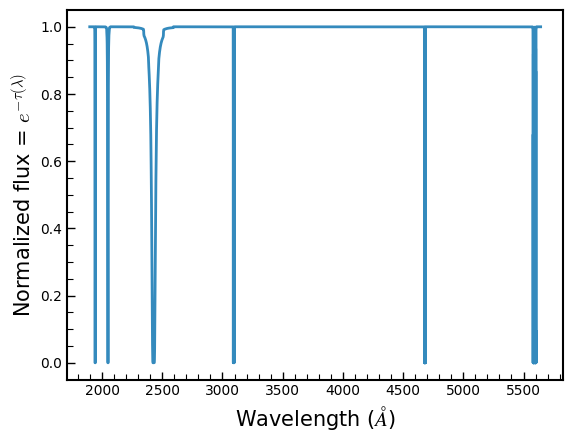

In [10]:
# We load our spectrum, note that the columns are wavelength, optical depth, flux, and flux error

spectrum = np.loadtxt('spectra/spectrum_DTB.txt')

plt.plot(spectrum[:,0], spectrum[:,2])
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)

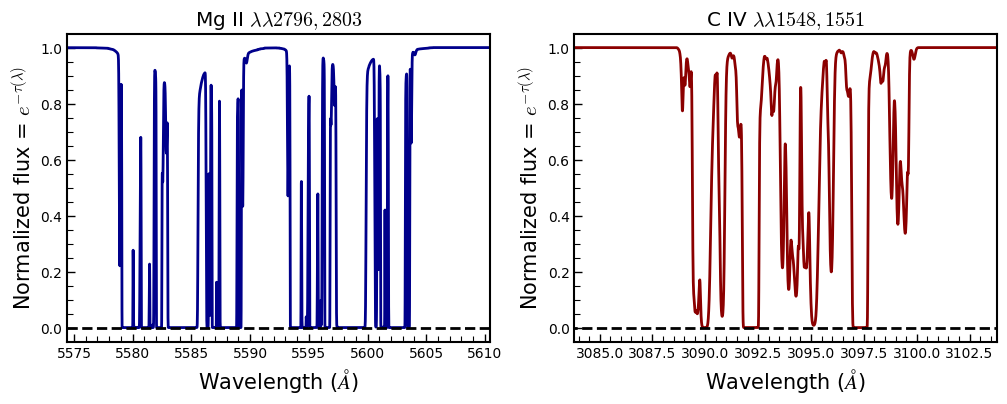

In [11]:
# Let's have a look at Mg II and C IV doublets individual species. 

plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(spectrum[:,0], spectrum[:,2],  color='darkblue')
plt.xlim((1+z) * 2800 - 18, (1+z) * 2800 + 18) 
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 2800 - 18, (1+z) * 2800 + 18, linestyle='--', color='black')
plt.title(r'Mg II $\lambda\lambda 2796,2803$')

plt.subplot(122)
plt.plot(spectrum[:,0], spectrum[:,2], color='darkred')
plt.xlim((1+z) * 1549 - 10, (1+z) * 1549 + 10) 
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 1549 - 18, (1+z) * 1549 + 18, linestyle='--', color='black')
plt.title(r'C IV $\lambda\lambda 1548,1551$')

plt.show()

This would be outcome of a noiseless infinite spectral resolution (only limited by the pixel sampling). 

Let's make it a bit more realistic by including the effect of spectral resolution. We will produce two versions of our spectra at $R=40000$ and $R=2000$, then rebin the final outcome. 

In [18]:
from scipy.ndimage import gaussian_filter1d   # We are going to assume the LSF is a gaussian

# We need to provide the "sigma" of the kernel in pixel units
R_high = 40000
R_low = 2000

# I'm going to focus only on the Mg II doublet, but note that the FWHM of the line typically changes with wavelength,
# so a more careful approach is needed to apply it to the full wavelength "coverage" we set. 

fwhm_sigma_high = ((1+z) * 2800) / R_high
fwhm_sigma_low = ((1+z) * 2800) / R_low 

sigma_high =  fwhm_sigma_high / 2.355       # for a gaussian, the FWHM ~ 2.355 * sigma 
sigma_low =  fwhm_sigma_low / 2.355

sigma_high_pixels = sigma_high / 0.01  # conversion to pixel units (remember our pixel size is 0.01 A)
sigma_low_pixels = sigma_high / 0.01 

high_R_spectrum = gaussian_filter1d(spectrum[:,2], sigma_high_pixels)
low_R_spectrum = gaussian_filter1d(spectrum[:,2], sigma_high_pixels)

In [19]:
# Finally, we rebin the spectra
import spectres  # package to rebin astronomical spectra, you can use other tools like specutils if you prefer

In [20]:
wavelength = spectrum[:,0]

new_wave_low_R = np.arange(wavelength[0], wavelength[-1], 1.25)
new_wave_high_R = np.arange(wavelength[0], wavelength[-1], 0.1)

rebin_low_R_spectrum = spectres.spectres(new_wave_low_R, wavelength, low_R_spectrum) 
rebin_high_R_spectrum = spectres.spectres(new_wave_high_R, wavelength, high_R_spectrum) 


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 


Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 



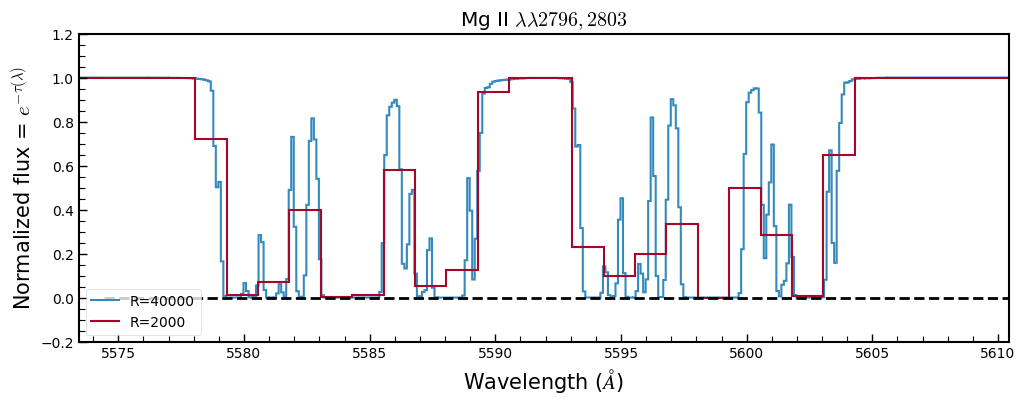

In [26]:
# Let's have a look at Mg II at different spectral resolutions!
wavelength_edges = np.concatenate((wavelength - 0.01/2, [wavelength[-1] + 0.01/2]))
wavelength_edges_low = np.concatenate((new_wave_low_R - 1.25/2, [new_wave_low_R[-1] + 1.25/2]))
wavelength_edges_high = np.concatenate((new_wave_high_R -0.1/2, [new_wave_high_R[-1] + 0.1/2]))

plt.figure(figsize=(12,4))

plt.stairs(rebin_high_R_spectrum[35000:], edges=wavelength_edges_high[35000:], linewidth=1.5, label='R=40000')
plt.stairs(rebin_low_R_spectrum[2800:], edges=wavelength_edges_low[2800:], linewidth=1.5, label='R=2000')

plt.xlim((1+z) * 2800 - 19, (1+z) * 2800 + 18) 
plt.ylim(-0.2, 1.2)
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 2800 - 18, (1+z) * 2800 + 18, linestyle='--', color='black')

plt.legend()
plt.title(r'Mg II $\lambda\lambda 2796,2803$')
plt.show()


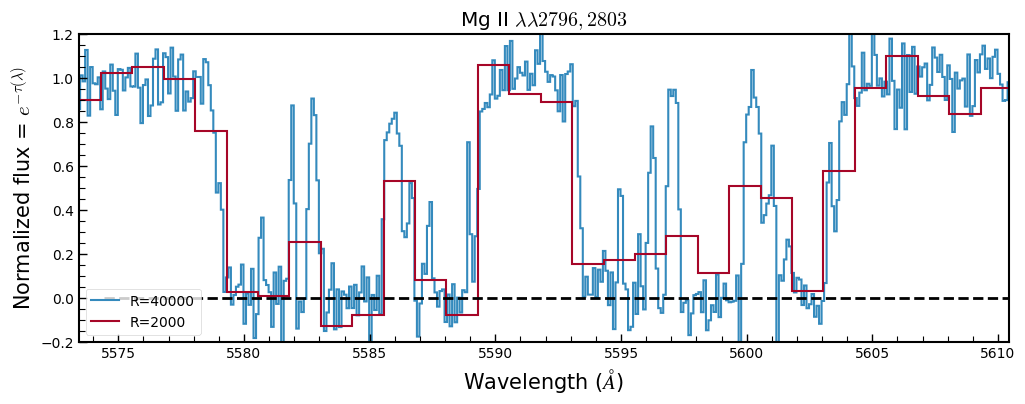

In [25]:
# We can make it noisy too

noise_low_r = np.random.normal(loc=0, scale=0.1, size=rebin_low_R_spectrum[2800:].shape) 
noise_high_r = np.random.normal(loc=0, scale=0.1, size=rebin_high_R_spectrum[35000:].shape)

plt.figure(figsize=(12,4))

plt.stairs(rebin_high_R_spectrum[35000:] + noise_high_r, edges=wavelength_edges_high[35000:], linewidth=1.5, label='R=40000')
plt.stairs(rebin_low_R_spectrum[2800:] + noise_low_r, edges=wavelength_edges_low[2800:], linewidth=1.5, label='R=2000')

plt.xlim((1+z) * 2800 - 19, (1+z) * 2800 + 18)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Normalized flux = $e^{-\tau(\lambda)}$', fontsize=15)
plt.hlines(0, (1+z) * 2800 - 18, (1+z) * 2800 + 18, linestyle='--', color='black')

plt.legend()
plt.title(r'Mg II $\lambda\lambda 2796,2803$')
plt.show()

Note that this is a very simplistic approach to add **uncorrelated noise**. 

In general, I would advice to not add noise to the spectra, as it would only produce an artificial scatter in the final analysis.
It can be useful to create a convincing figure for a proposal though! 

We can also add a background QSO to our spectrum, directly using TRIDENT. 
Let's add a background QSO at z=1.5. 


In [27]:
# We will use the same "spectrum_generator" object of the last cells.
name_spectrum = 'spectra/spectra_DTB_qso_background.txt'
sg.add_qso_spectrum(emitting_redshift=1.5)
sg.save_spectrum(name_spectrum)

yt : [INFO     ] 2025-06-27 13:06:30,478 Writing spectrum to ascii file: spectra/spectra_DTB_qso_background.txt.


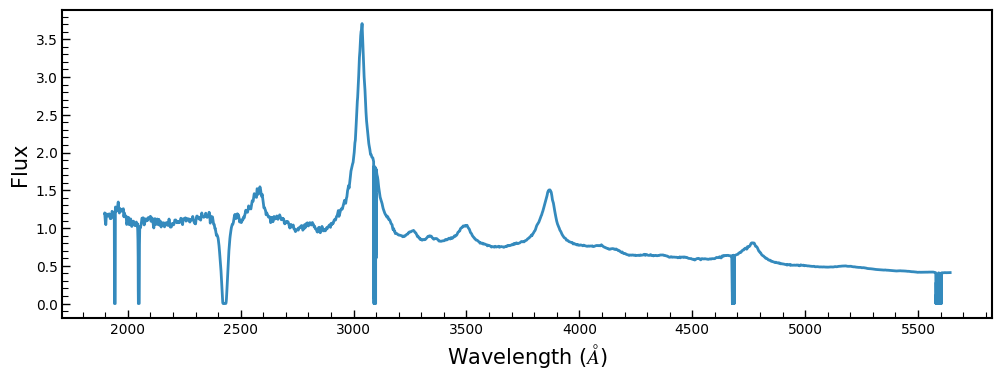

In [32]:
spectrum = np.loadtxt('spectra/spectra_DTB_qso_background.txt')
plt.figure(figsize=(12,4))
plt.plot(spectrum[:,0], spectrum[:,2])
plt.xlabel(r'Wavelength ($\AA$)', fontsize=15)
plt.ylabel(r'Flux (arbitrary units)', fontsize=15)
plt.show()

TRIDENT uses the  SDSS QSO composite spectrum from [Telfer et al. 2002](https://arxiv.org/pdf/astro-ph/0109531). But in principle, if you have a template spectrum for a background source, you can just multiply it with the TRIDENT normalized spectrum to add your custom background source. 

## Many rays!

Now, we will do an experiment to illustrate possible experiments you can do with TRIDENT. 
We will dive into the gas kinematics. To this end, we will pierce our galaxy in an edge-on orientation, along the major axis of the galaxy, and produce an radial velocity map from our mock spectra. 

To do this we will use the same geometry setup from before. 

In [8]:
# We compute the angular momentum
sp = ds.sphere(center, (0.1 * R_vir.value, 'kpc'))

P_edge_on, N_edge_on, W_edge_on = coords.create_PNW_base(ds, 0, center,0.1 * R_vir.value)        # edge on
P_face_on, N_face_on, W_face_on = coords.create_PNW_base(ds, np.pi/2, center,0.1 * R_vir.value)          # face on

In [11]:
N_rays = 51
delta_center = np.linspace(-50, 50, N_rays)

center_kpc = center * ds.length_unit.in_units('kpc')
center_PNW = coords.sim_to_pnw_coords(center_kpc, P_edge_on, N_edge_on, W_edge_on)

# We will create all of our rays in the PNW coordinates, so that rays a simply parallel to the P vector and shifted in the W direction.

start_positions_PNW  = np.zeros((N_rays, 3)) 
start_positions_PNW[:,0] = -R_vir.value/2 + center_PNW[0]
start_positions_PNW[:,1] = center_PNW[1]
start_positions_PNW[:,2] = delta_center + center_PNW[2]

end_positions_PNW  = np.zeros((N_rays, 3)) 
end_positions_PNW[:,0] = R_vir.value/2 + center_PNW[0]
end_positions_PNW[:,1] = center_PNW[1]
end_positions_PNW[:,2] = delta_center + center_PNW[2]

start_positions_sim_coords = np.zeros((N_rays,3)) * kpc 
end_positions_sim_coords = np.zeros((N_rays,3)) * kpc

# Conversion from PNW to simulation coordinates
for i in range(N_rays):
    start_positions_sim_coords[i,:] = coords.pnw_to_sim_coords(start_positions_PNW[i,:], P_edge_on, N_edge_on, W_edge_on) 
    end_positions_sim_coords[i,:] = coords.pnw_to_sim_coords(end_positions_PNW[i,:], P_edge_on, N_edge_on, W_edge_on) 


In [10]:
# For visualization purposes :) 
projection_edge_on = yt.OffAxisProjectionPlot(ds, P_edge_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(1.2*R_vir.value, 'kpc'), north_vector=N_edge_on)
projection_face_on = yt.OffAxisProjectionPlot(ds, P_face_on, fields= ('gas', 'Mg_p1_number_density'), center=sp.center,
                                            width=(1.2*R_vir.value, 'kpc'), north_vector=N_face_on)

yt : [INFO     ] 2025-06-27 13:34:20,608 xlim = -140.651940 140.651940
yt : [INFO     ] 2025-06-27 13:34:20,609 ylim = -140.651940 140.651940
yt : [INFO     ] 2025-06-27 13:34:20,610 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-27 13:34:20,612 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800


yt : [WARNING  ] 2025-06-27 13:34:48,160 Plotting ('gas', 'Mg_p1_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 4.926394772770468e+17 cm**(-2).
yt : [WARNING  ] 2025-06-27 13:34:48,161 Switching to symlog colorbar scaling.
yt : [INFO     ] 2025-06-27 13:34:48,849 xlim = -140.651940 140.651940
yt : [INFO     ] 2025-06-27 13:34:48,850 ylim = -140.651940 140.651940
yt : [INFO     ] 2025-06-27 13:34:48,852 zlim = -17500.000000 17500.000000
yt : [INFO     ] 2025-06-27 13:34:48,852 Making a fixed resolution buffer of (('gas', 'Mg_p1_number_density')) 800 by 800
yt : [WARNING  ] 2025-06-27 13:35:19,226 Plotting ('gas', 'Mg_p1_number_density'): Both positive and negative values. Min = 0.0 cm**(-2), Max = 1.592098152605644e+17 cm**(-2).
yt : [WARNING  ] 2025-06-27 13:35:19,226 Switching to symlog colorbar scaling.


In [11]:
%%bash
mkdir rays
mkdir spectra

In [12]:
# Creating rays
# Recommendation: rays production is independent from each other therefore, when generating several rays, it is highly
# recommended that you use some parallelization to speed up the process. 
# Each ray in my computer takes like 8 seconds to be generated, therefore this cell takes like 7 minutes to run.
# with parallelization this may take like 20 seconds only! 

rays = []
for i in range(N_rays):
    print(f'Doing ray {i+1} out of {N_rays}.')
    ray = trident.make_simple_ray(ds,
                              start_position=[start_positions_sim_coords[i,:][j].value * kpc for j in range(3)],
                              end_position=[end_positions_sim_coords[i,:][j].value * kpc for j in range(3)],
                              data_filename=f"rays/ray_{i}.h5",
                              lines=['Mg II 2796', 'C IV 1548'], line_database='database_tutorial.txt')
    rays.append(ray)

yt : [INFO     ] 2025-06-27 13:38:17,463 Getting segment at z = 0.9972942257819404: [0.7648042  0.08905329 0.19355008] unitary to [0.76950898 0.0938203  0.19355008] unitary.
c:\ProgramData\Anaconda3\lib\site-packages\unyt\array.py:1906: RuntimeWarning: invalid value encountered in divide
  out_arr = func(
yt : [INFO     ] 2025-06-27 13:38:17,466 Getting subsegment: [0.7648042  0.08905329 0.19355008] unitary to [0.76950898 0.0938203  0.19355008] unitary.


Doing ray 1 out of 51.


yt : [INFO     ] 2025-06-27 13:38:24,395 Saving field data to yt dataset: rays/ray_0.h5.
yt : [INFO     ] 2025-06-27 13:38:24,480 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:38:24,481 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:38:24,482 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:38:24,483 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:38:24,483 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:38:24,484 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:38:24,485 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:38:24,486 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:38:24,486 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:38:24,487 Parameters:

Doing ray 2 out of 51.


yt : [INFO     ] 2025-06-27 13:38:31,648 Saving field data to yt dataset: rays/ray_1.h5.
yt : [INFO     ] 2025-06-27 13:38:31,729 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:38:31,729 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:38:31,731 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:38:31,732 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:38:31,733 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:38:31,734 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:38:31,735 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:38:31,736 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:38:31,738 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:38:31,738 Parameters:

...

yt : [INFO     ] 2025-06-27 13:44:37,658 Saving field data to yt dataset: rays/ray_48.h5.
yt : [INFO     ] 2025-06-27 13:44:37,726 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:44:37,728 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:44:37,730 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:44:37,731 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:44:37,733 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:44:37,734 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:44:37,735 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:44:37,736 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:44:37,738 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:44:37,739 Parameters

Doing ray 50 out of 51.


yt : [INFO     ] 2025-06-27 13:44:44,263 Saving field data to yt dataset: rays/ray_49.h5.
yt : [INFO     ] 2025-06-27 13:44:44,323 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:44:44,324 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:44:44,326 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:44:44,329 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:44:44,330 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:44:44,331 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:44:44,332 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:44:44,333 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:44:44,335 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:44:44,336 Parameters

Doing ray 51 out of 51.


yt : [INFO     ] 2025-06-27 13:44:51,701 Saving field data to yt dataset: rays/ray_50.h5.
yt : [INFO     ] 2025-06-27 13:44:51,773 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:44:51,774 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:44:51,774 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:44:51,776 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:44:51,778 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:44:51,779 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:44:51,779 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:44:51,780 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:44:51,781 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:44:51,782 Parameters

In [13]:
# We can check that our rays are going though the galaxy as we expect by annotating the rays in our plots
for ray in rays[::3]:
    projection_face_on.annotate_ray(ray, arrow=True)

In [58]:
for ray in rays[::3]:
    projection_edge_on.annotate_ray(ray, arrow=True)

c:\ProgramData\Anaconda3\lib\site-packages\unyt\array.py:1906: RuntimeWarning: invalid value encountered in divide
  out_arr = func(



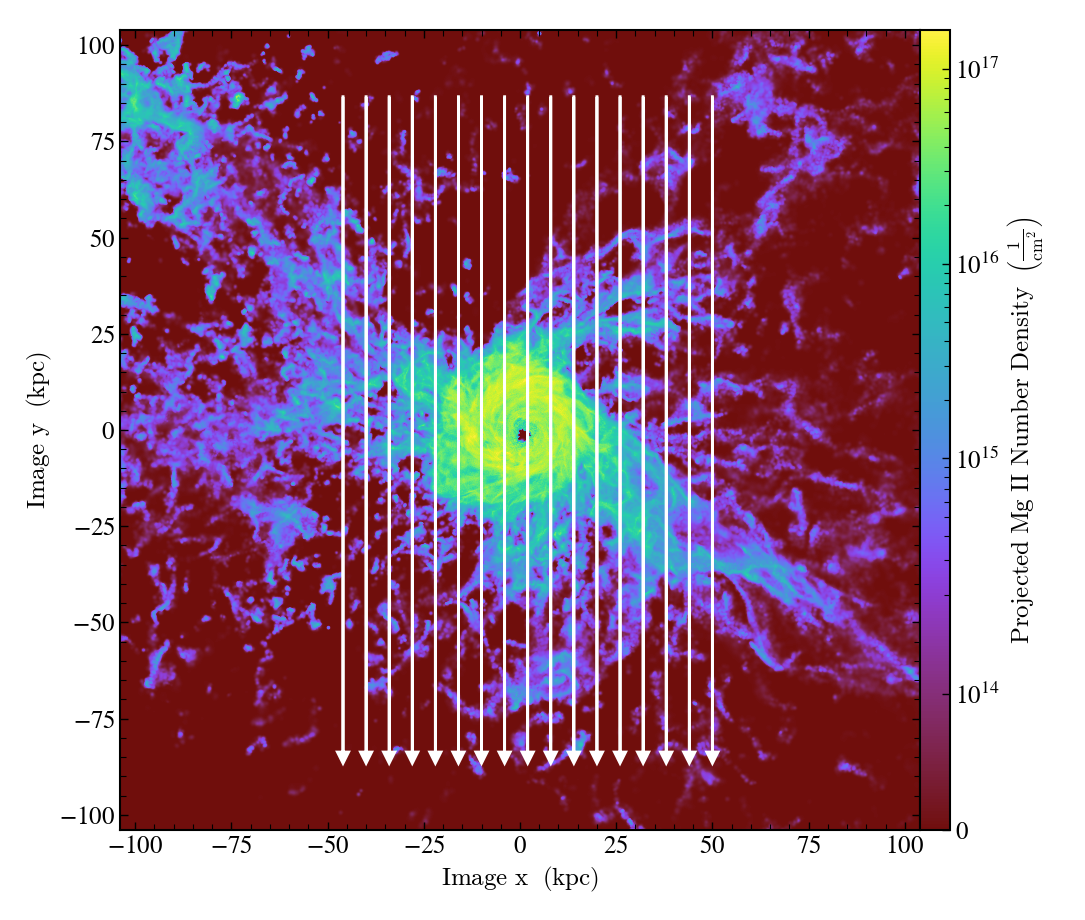

In [14]:
projection_face_on

c:\ProgramData\Anaconda3\lib\site-packages\unyt\array.py:1906: RuntimeWarning: invalid value encountered in divide
  out_arr = func(



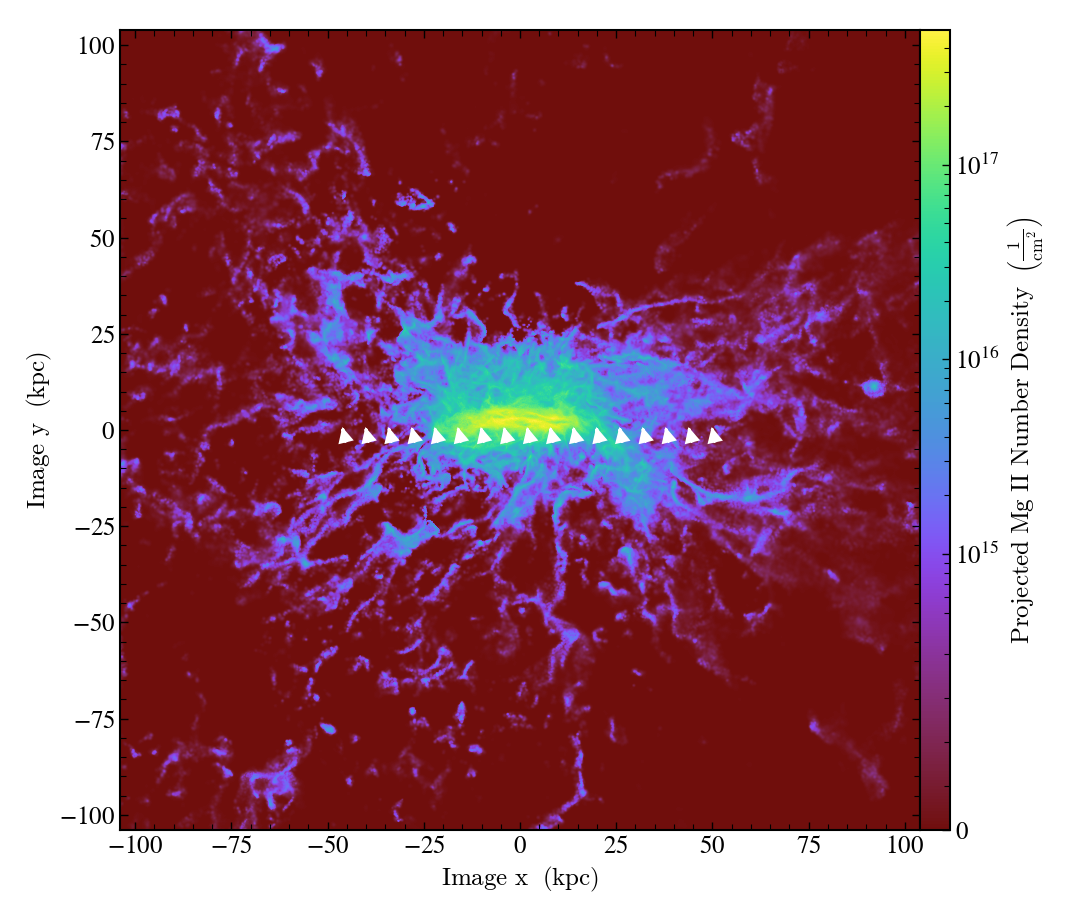

In [59]:
projection_edge_on

In [ ]:
# Now we generate the spectra
sp_path = 'spectra/'
lines_list = ['Mg II 2796', 'C IV 1548']
z = ds.current_redshift

# We will produce one spectrum for each species, to save some memory.
# We iterate over each species for which we want to generate an spectrum.
for species in lines_list:
    wavelength = int(species.split(' ')[2])    # String are "Element Ionization Lambda"
    path_species = sp_path + species.replace(' ', '_')
    try:
        os.mkdir(path_species)
    except:
        pass
    
    for i in range(N_rays):
        ray_name = f'rays/ray_{i}.h5'
        name_spectrum = path_species + f'/spectrum_{i}.txt'
        min_lambda = (1+z) * wavelength - 25
        max_lambda = (1+z) * wavelength + 25
        sg = trident.SpectrumGenerator(lambda_min=min_lambda, lambda_max=max_lambda,
                                                        dlambda=0.01, line_database='database_tutorial.txt')
        sg.make_spectrum(ray_name, lines=lines_list)
        sg.save_spectrum(name_spectrum)

yt : [INFO     ] 2025-06-27 13:44:52,774 Setting instrument to Custom
yt : [INFO     ] 2025-06-27 13:44:52,856 Parameters: current_time              = 1.8549657447095306e+17 s
yt : [INFO     ] 2025-06-27 13:44:52,857 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2025-06-27 13:44:52,858 Parameters: domain_left_edge          = [0. 0. 0.] code_length
yt : [INFO     ] 2025-06-27 13:44:52,859 Parameters: domain_right_edge         = [35000. 35000. 35000.] code_length
yt : [INFO     ] 2025-06-27 13:44:52,860 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2025-06-27 13:44:52,862 Parameters: current_redshift          = 0.9972942257819404
yt : [INFO     ] 2025-06-27 13:44:52,863 Parameters: omega_lambda              = 0.6911
yt : [INFO     ] 2025-06-27 13:44:52,864 Parameters: omega_matter              = 0.3089
yt : [INFO     ] 2025-06-27 13:44:52,865 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-06-27 13:44:52,867 Parameters: hubble_constant   

In [ ]:
# We now load all our generated_spectra for MgII and CIV and compute basic things like EW and a line centroid

mg_ii_spectra = np.array([np.loadtxt(f'spectra/Mg_II_2796/spectrum_{i}.txt', usecols=(0,2)) for i in range(N_rays)])
c_iv_spectra = np.array([np.loadtxt(f'spectra/C_IV_1548/spectrum_{i}.txt', usecols=(0,2)) for i in range(N_rays)])

delta_wave = 0.01 # angstrom
z = ds.current_redshift
mg_ii_spectra.shape

ew_mgii = np.trapz( (1-mg_ii_spectra[:,:,1]), axis=1, dx=delta_wave) / (1 + z)  # divide by (1+z) to make it rest frame :)
ew_civ = np.trapz( (1-c_iv_spectra[:,:,1]), axis=1, dx=delta_wave) / (1 + z) 


(0.0, 4.0)

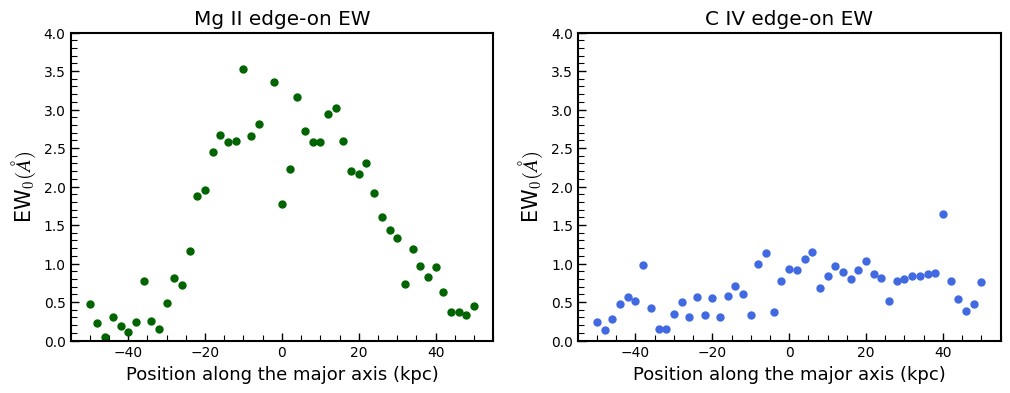

In [57]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(-delta_center, ew_mgii, 'o', markersize=5, color='darkgreen')

plt.xlim(-55,55)
plt.title('Mg II edge-on EW')
plt.xlabel('Position along the major axis (kpc)', fontsize=13)
plt.ylabel(r'EW$_0 (\AA)$', fontsize=15)
plt.ylim(0, 4)

plt.subplot(122)
plt.plot(-delta_center, ew_civ, 'o', markersize=5, color='royalblue')

plt.xlim(-55,55)
plt.title('C IV edge-on EW')
plt.xlabel('Position along the major axis (kpc)', fontsize=13)
plt.ylabel(r'EW$_0 (\AA)$', fontsize=15)
plt.ylim(0, 4)

We will also compute the line centroids, defined as

$$<\lambda> = \frac{\int (1 - f_{norm}(\lambda)) \lambda d \lambda}{\int (1 - f_{norm}(\lambda)) d \lambda} $$

In [17]:
centroid_mgii = np.sum( (1-mg_ii_spectra[:,:,1]) * mg_ii_spectra[:,:,0], axis=1) / np.sum((1-mg_ii_spectra[:,:,1]), axis=1)  
centroid_civ = np.sum( (1-c_iv_spectra[:,:,1]) * c_iv_spectra[:,:,0], axis=1) / np.sum((1-c_iv_spectra[:,:,1]), axis=1)  

In [18]:
# To velocity conversion
from scipy.constants import c 
mgii_lambda0 = 2796.352
civ_lambda0 = 1548.187

vel_mgii = (c/1000) * (centroid_mgii - (1+z) * mgii_lambda0) / ((1+z) * mgii_lambda0)
vel_civ = (c/1000) * (centroid_civ - (1+z) * civ_lambda0) / ((1+z) * civ_lambda0)

In [30]:
systemic_vel = (velocity_gal * P_edge_on).sum().value

As described in the [TRIDENT paper](https://iopscience.iop.org/article/10.3847/1538-4357/aa7e2d/pdf), the ending point of the ray is considered the position of the observer, therefore, the projected velocity measured along the ray is actually in the opposite direction of the ray. 

Therefore, we need to multiply by (-1) our "systemic velocity" computed in the last cell to compare with the velocity along the ray we measured with the line centroids.

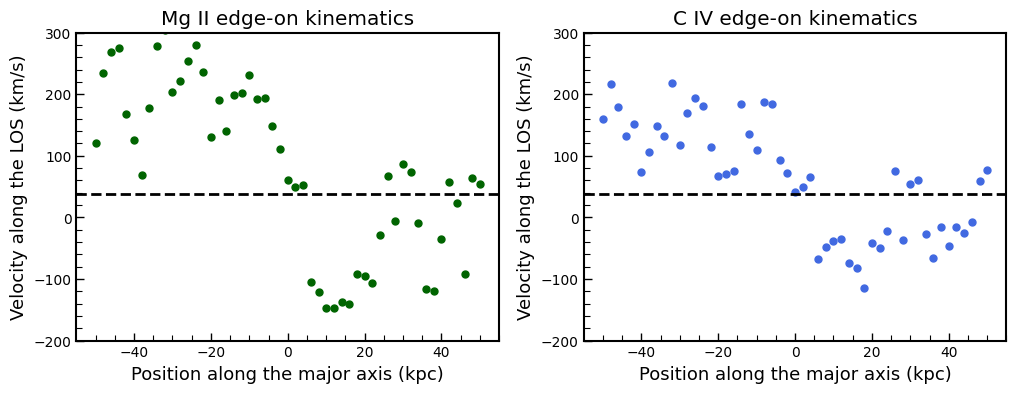

In [63]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(delta_center, vel_mgii, 'o', markersize=5, color='darkgreen')

plt.hlines(-systemic_vel, -55, 55, linestyle='--', color='black')  # negative sign as discussed before!
plt.xlim(-55,55)
plt.title('Mg II edge-on kinematics')
plt.xlabel('Position along the major axis (kpc)', fontsize=13)
plt.ylabel('Velocity along the LOS (km/s)', fontsize=13)
plt.ylim(-200, 300)

plt.subplot(122)
plt.plot(delta_center, vel_civ, 'o', markersize=5, color='royalblue')
plt.hlines(-systemic_vel, -55, 55, linestyle='--', color='black')
plt.xlim(-55,55)
plt.title('C IV edge-on kinematics')
plt.xlabel('Position along the major axis (kpc)', fontsize=13)
plt.ylabel('Velocity along the LOS (km/s)', fontsize=13)
plt.ylim(-200, 300)

plt.show()

Both plots show quite strong differences. With Mg II EW tracing the abundance of cool gas in the ISM of the galaxy, while C IV traces a "volume filling" phase showing a very uniform EW profile as a function of distance. 

Kinematics show that both gases follow the galaxy rotation curve, but with Mg II reaching higher velocities, with an apparent wider velocity distribution. 

That's it! I hope this tutorial gave you the basics on how to produce and deal with TRIDENT-generated mock spectra. 

For more "inspiration" check [all the papers that are using TRIDENT!](https://ui.adsabs.harvard.edu/search/q=citations(bibcode%3A2017ApJ...847...59H)&sort=date%20desc%2C%20bibcode%20desc&p_=0). 